# Hindbrain Rising- Versus Falling-Flank c-GC

This notebook applies the current rising/falling-flank pipeline to the Zenodo hindbrain dataset in `data/hindbrain/df_hindbrain_F6T07.pkl`.

By default it analyzes the medial motor-correlated subset because that is the Chen-comparable hindbrain subset in `data/README.txt` and keeps the c-GC run tractable. Set `RF_HINDBRAIN_SUBSET=swim` or `RF_HINDBRAIN_SUBSET=all` only when you intentionally want a larger run; raise `RF_MAX_NODES` if needed.

The saved `adjacency` matrices are weighted retained c-GC score matrices in `[source, target]` orientation. Zero means no retained edge; the boolean retained-edge support is stored separately as `mask`.


<!-- reviewer-resume-contract -->
## Execution and resume contract

This notebook is aligned with the reviewer-revision implementation. Expensive work is checkpointed and safe to restart with the same configuration. Do not change methods, seeds, thresholds, or output paths while resuming. Saved outputs remain provisional until the compute-machine run and verification gates complete.


In [1]:
from pathlib import Path
import hashlib
import os
import pickle
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PACKAGE_RELATIVE_PATH = Path("src/calcium_transient_rising_flank")


def find_project_root() -> Path:
    search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for base in search_roots:
        for candidate in (base, base / "calcium-transient-rising-flank"):
            if (candidate / PACKAGE_RELATIVE_PATH).exists():
                return candidate
    raise FileNotFoundError(
        "Could not find the calcium-transient-rising-flank repository; "
        "run from the repository, notebooks directory, or outer rising_flanks workspace."
    )


PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from calcium_transient_rising_flank import (
    CausalisedGC,
    build_representations,
    plot_topographic_graph,
    selected_frame_indices,
    write_summary_csv,
)
from calcium_transient_rising_flank.checkpointing import atomic_write_pickle, load_pickle as load_checkpoint_pickle

HINDBRAIN_SUBSET = os.environ.get("RF_HINDBRAIN_SUBSET", "medial")
MAX_NODES = int(os.environ.get("RF_MAX_NODES", "40"))
MAX_LAG = int(os.environ.get("RF_MAX_LAG", "3"))
N_PERMUTATIONS = int(os.environ.get("RF_N_PERMUTATIONS", "1000"))
SIGNIFICANCE_ALPHA = float(os.environ.get("RF_ALPHA", "0.05"))
RANDOM_STATE = int(os.environ.get("RF_RANDOM_STATE", "10"))
PLOT_MODE = os.environ.get("RF_HINDBRAIN_PLOT_MODE", "abstract")  # abstract or topographic

DATA_FILE = PROJECT_ROOT / "data" / "hindbrain" / "df_hindbrain_F6T07.pkl"
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Expected hindbrain dataframe at {DATA_FILE}")

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "motorneurons"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = PROJECT_ROOT.parent / "figures"
ADJACENCY_OUTPUT_FILE = OUTPUT_DIR / f"rising_flanks_hindbrain_{HINDBRAIN_SUBSET}_weighted_adjacency_matrices.pkl"
SUMMARY_OUTPUT_FILE = OUTPUT_DIR / f"rising_flanks_hindbrain_{HINDBRAIN_SUBSET}_summary_rows.pkl"
SUMMARY_CSV_OUTPUT_FILE = OUTPUT_DIR / f"rising_flanks_hindbrain_{HINDBRAIN_SUBSET}_summary_rows.csv"
RESUME = True
IMPLEMENTATION_REVISION = 'reviewer-2026-08-v2'
FIT_CHECKPOINT_DIR = OUTPUT_DIR / 'notebook_checkpoints' / 'rise_fall_hindbrain'
FIGURE_OUTPUT_FILE = FIGURE_DIR / f"rising_flanks_hindbrain_{HINDBRAIN_SUBSET}_rise_fall.png"

print(f"Project root: {PROJECT_ROOT}")
print(f"Using hindbrain data file: {DATA_FILE}")
print(
    f"subset={HINDBRAIN_SUBSET}; max_lag={MAX_LAG}; n_perm={N_PERMUTATIONS}; "
    f"alpha={SIGNIFICANCE_ALPHA}"
)


Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank
Using hindbrain data file: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/hindbrain/df_hindbrain_F6T07.pkl
subset=medial; max_lag=3; n_perm=1000; alpha=0.01


## Load Hindbrain Data


In [2]:
def _first_record(obj):
    if isinstance(obj, pd.DataFrame):
        if len(obj) != 1:
            print(f"Hindbrain dataframe has {len(obj)} rows; using the first row.")
        return obj.iloc[0]
    return obj


def _field(record, name, default=None):
    if isinstance(record, dict) and name in record:
        return record[name]
    try:
        return record[name]
    except Exception:
        pass
    if hasattr(record, name):
        return getattr(record, name)
    if default is not None:
        return default
    raise KeyError(f"Missing hindbrain field: {name}")


def _indices(values, n_cells):
    arr = np.asarray(values)
    if arr.dtype == bool:
        if arr.shape != (n_cells,):
            raise ValueError(f"Boolean index has shape {arr.shape}, expected {(n_cells,)}")
        return np.flatnonzero(arr)
    return arr.astype(int)


def _clean_traces(raw, expected_cells=None):
    values = np.asarray(raw, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Expected 2-D traces, got shape {values.shape}")
    if expected_cells is not None and values.shape[0] != expected_cells and values.shape[1] == expected_cells:
        values = values.T
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    if values.shape[0] > values.shape[1]:
        raise ValueError(
            f"Trace matrix looks transposed or too short: {values.shape}. Expected [n_cells, n_timepoints]."
        )
    return values


def load_hindbrain_record(path):
    record = _first_record(pd.read_pickle(path))
    fluo = np.asarray(_field(record, "fluo"), dtype=float)
    n_cells = int(_field(record, "n_cells", fluo.shape[0]))
    fluo = _clean_traces(fluo, expected_cells=n_cells)
    n_cells = fluo.shape[0]

    if HINDBRAIN_SUBSET == "medial":
        selected = _indices(_field(record, "medial_neurons"), n_cells)
    elif HINDBRAIN_SUBSET in {"swim", "swim_neurons"}:
        selected = _indices(_field(record, "swim_neurons"), n_cells)
    elif HINDBRAIN_SUBSET == "all":
        selected = np.arange(n_cells, dtype=int)
    else:
        raise ValueError("RF_HINDBRAIN_SUBSET must be 'medial', 'swim', or 'all'.")

    if selected.size == 0:
        raise ValueError(f"Subset {HINDBRAIN_SUBSET!r} selected no neurons.")
    traces = fluo[selected]
    if traces.shape[0] > MAX_NODES:
        raise ValueError(
            f"Subset {HINDBRAIN_SUBSET!r} has {traces.shape[0]} neurons, above RF_MAX_NODES={MAX_NODES}. "
            "Use the medial subset, raise RF_MAX_NODES, or expect a long c-GC run."
        )

    centers = np.asarray(_field(record, "cell_centers"), dtype=float)
    selected_centers = centers[selected] if centers.shape[0] == n_cells else None
    return {
        "recording": "F6T07",
        "subset": HINDBRAIN_SUBSET,
        "indices": selected,
        "traces": traces,
        "cell_centers": selected_centers,
        "background": _field(record, "background", None),
        "n_cells_total": int(n_cells),
        "n_cells": int(traces.shape[0]),
        "n_timepoints": int(traces.shape[1]),
    }


record = load_hindbrain_record(DATA_FILE)
print(
    f"Loaded {record['recording']} {record['subset']} subset: "
    f"{record['n_cells']} of {record['n_cells_total']} cells x {record['n_timepoints']} frames"
)


Loaded F6T07 medial subset: 20 of 139 cells x 1744 frames


## Visualize Extracted Rising Flanks on Raw Hindbrain Transient

This cell overlays extracted rising-flank samples as red markers on a representative raw hindbrain calcium transient. It can be run immediately after the hindbrain data-loading cell; it does not require running the c-GC fitting cells.


Plotted subset ROI 9; visible rising samples=185; total rising samples=880
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/rising_flank_overlay_hindbrain_F6T07_medial.pdf
Saved /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/rising_flank_overlay_hindbrain_F6T07_medial.png


(<Figure size 1008x364 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Fluorescence (a.u.)'>)

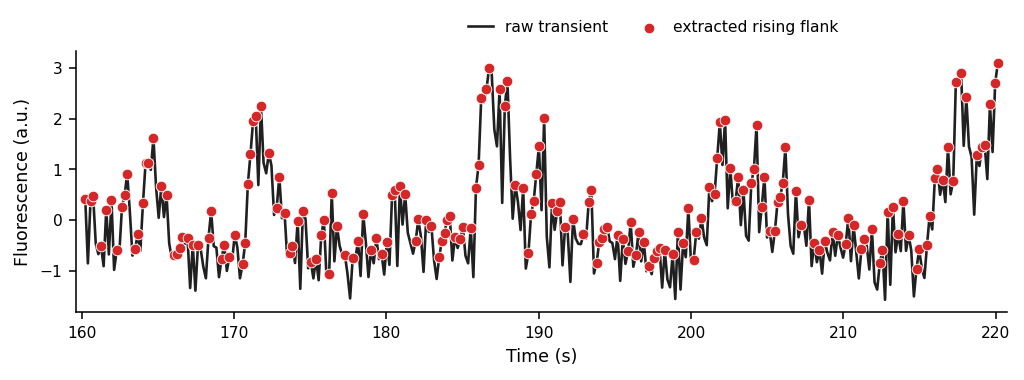

In [3]:
# Paper-ready overlay of extracted rising flanks on a raw hindbrain transient.
# Override with RF_RISE_PLOT_ROI, RF_RISE_WINDOW_SECONDS, RF_HINDBRAIN_SAMPLING_HZ,
# or RF_RISE_SHOW_TITLE=1 if you want a title inside the saved figure.

HINDBRAIN_RISE_PLOT_ROI = os.environ.get("RF_RISE_PLOT_ROI")
HINDBRAIN_RISE_WINDOW_SECONDS = float(os.environ.get("RF_RISE_WINDOW_SECONDS", "60"))
HINDBRAIN_SAMPLING_HZ = float(os.environ.get("RF_HINDBRAIN_SAMPLING_HZ", "5.81"))
SHOW_RISE_OVERLAY_TITLE = os.environ.get("RF_RISE_SHOW_TITLE", "0").lower() in {"1", "true", "yes"}


def _representative_roi(rise):
    event_counts = np.asarray([len(indices) for indices in selected_frame_indices(rise)], dtype=int)
    event_weight = rise.sum(axis=1)
    if event_counts.max(initial=0) == 0:
        return int(np.argmax(np.ptp(rise, axis=1)))
    return int(np.lexsort((event_weight, event_counts))[-1])


def _event_dense_window(event_indices, n_frames, window_frames):
    window_frames = int(min(max(window_frames, 20), n_frames))
    if window_frames >= n_frames or len(event_indices) == 0:
        return 0, n_frames
    binary = np.zeros(n_frames, dtype=float)
    binary[np.asarray(event_indices, dtype=int)] = 1.0
    scores = np.convolve(binary, np.ones(window_frames, dtype=float), mode="valid")
    start = int(np.argmax(scores))
    return start, start + window_frames


def plot_raw_trace_with_rising_flanks(
    traces,
    *,
    sampling_hz,
    title,
    output_stem,
    roi_index=None,
    original_indices=None,
    window_seconds=60.0,
):
    values = np.asarray(traces, dtype=float)
    representations = build_representations(values)
    rise = representations.rise
    event_indices = selected_frame_indices(rise)
    roi = _representative_roi(rise) if roi_index is None else int(roi_index)
    if roi < 0 or roi >= values.shape[0]:
        raise ValueError(f"roi_index={roi} is outside the available range 0..{values.shape[0] - 1}")

    event_frames = np.asarray(event_indices[roi], dtype=int)
    start, stop = _event_dense_window(
        event_frames,
        values.shape[1],
        int(round(window_seconds * sampling_hz)),
    )
    visible_events = event_frames[(event_frames >= start) & (event_frames < stop)]
    time = np.arange(start, stop, dtype=float) / sampling_hz
    original_label = ""
    if original_indices is not None:
        original_label = f"; original cell {int(np.asarray(original_indices)[roi])}"

    with plt.rc_context(
        {
            "figure.dpi": 140,
            "savefig.dpi": 300,
            "font.size": 9,
            "axes.labelsize": 9,
            "axes.titlesize": 10,
            "legend.fontsize": 8,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    ):
        fig, ax = plt.subplots(figsize=(7.2, 2.6), constrained_layout=True)
        ax.plot(
            time,
            values[roi, start:stop],
            color="#202020",
            lw=1.35,
            label="raw transient",
        )
        ax.scatter(
            visible_events / sampling_hz,
            values[roi, visible_events],
            s=30,
            color="#d62728",
            edgecolors="white",
            linewidths=0.45,
            zorder=3,
            label="extracted rising flank",
        )
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Fluorescence (a.u.)")
        if SHOW_RISE_OVERLAY_TITLE:
            ax.set_title(f"{title} (subset ROI {roi}{original_label})")
        ax.legend(
            frameon=False,
            loc="lower center",
            bbox_to_anchor=(0.62, 1.01),
            ncol=2,
            handlelength=1.6,
            columnspacing=1.8,
        )
        ax.margins(x=0.01)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    png_path = FIGURE_DIR / f"{output_stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Plotted subset ROI {roi}; visible rising samples={len(visible_events)}; total rising samples={len(event_frames)}")
    print(f"Saved {pdf_path}")
    print(f"Saved {png_path}")
    return fig, ax


hindbrain_roi = None if HINDBRAIN_RISE_PLOT_ROI is None else int(HINDBRAIN_RISE_PLOT_ROI)
plot_raw_trace_with_rising_flanks(
    record["traces"],
    sampling_hz=HINDBRAIN_SAMPLING_HZ,
    title=f"Hindbrain {record['recording']} {record['subset']} subset: rising-flank extraction",
    output_stem=f"rising_flank_overlay_hindbrain_{record['recording']}_{record['subset']}",
    roi_index=hindbrain_roi,
    original_indices=record["indices"],
    window_seconds=HINDBRAIN_RISE_WINDOW_SECONDS,
)


## Fit Rising and Falling Flank c-GC


In [4]:
def build_estimator():
    return CausalisedGC(
        max_lag=MAX_LAG,
        n_surrogates=N_PERMUTATIONS,
        alpha=SIGNIFICANCE_ALPHA,
        random_state=RANDOM_STATE,
        fdr=True,
        event_mode="physical",
    )


def generic_graph_summary(matrix):
    values = np.asarray(matrix, dtype=float).copy()
    if values.ndim != 2 or values.shape[0] != values.shape[1]:
        raise ValueError("adjacency matrix must be square")
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(values, 0.0)
    off_diag = ~np.eye(values.shape[0], dtype=bool)
    retained = values[off_diag] > 0.0
    out_strength = values.sum(axis=1)
    in_strength = values.sum(axis=0)
    opportunities = int(np.count_nonzero(off_diag))
    retained_edges = int(np.count_nonzero(retained))
    return {
        "n_nodes": int(values.shape[0]),
        "w_ic": None,
        "w_rc": None,
        "delta_w_ic_rise_minus_fall": None,
        "delta_w_rc_rise_minus_fall": None,
        "retained_edges": retained_edges,
        "edge_opportunities": opportunities,
        "edge_density": retained_edges / opportunities if opportunities else None,
        "total_weight": float(values[off_diag].sum()),
        "mean_out_strength": float(np.mean(out_strength)) if out_strength.size else 0.0,
        "mean_in_strength": float(np.mean(in_strength)) if in_strength.size else 0.0,
        "max_out_strength": float(np.max(out_strength)) if out_strength.size else 0.0,
        "max_in_strength": float(np.max(in_strength)) if in_strength.size else 0.0,
    }


def _graph_payload(graph, event_indices):
    weighted_adjacency = np.asarray(graph.retained_scores, dtype=float)
    return {
        "adjacency": weighted_adjacency,
        "weighted_adjacency": weighted_adjacency,
        "mask": np.asarray(graph.adjacency, dtype=bool),
        "scores": np.asarray(graph.scores, dtype=float),
        "p_values": np.asarray(graph.p_values, dtype=float),
        "best_lags": np.asarray(graph.best_lags, dtype=int),
        "estimator": graph.estimator,
        "event_counts": np.asarray([len(values) for values in event_indices], dtype=int),
    }


traces = record["traces"]
representations = build_representations(traces)
phases = {"rise": representations.rise, "fall": representations.fall}
graphs = {}
summary_rows = []

for index, (phase, representation) in enumerate(phases.items(), start=1):
    event_indices = selected_frame_indices(representation)
    counts = np.asarray([len(values) for values in event_indices], dtype=int)
    print(
        f"[{index}/{len(phases)}] Fitting {phase}: "
        f"median selected frames={np.median(counts):.0f}; min={counts.min()}; max={counts.max()}",
        flush=True,
    )
    data_digest = hashlib.sha256(np.ascontiguousarray(traces).view(np.uint8)).hexdigest()
    checkpoint_key = f"{record['recording']}|{record['subset']}|{phase}|{data_digest}"
    checkpoint_name = hashlib.sha256(checkpoint_key.encode()).hexdigest() + '.pkl'
    checkpoint = FIT_CHECKPOINT_DIR / checkpoint_name
    fit_config = {
        'revision': IMPLEMENTATION_REVISION, 'phase': phase, 'max_lag': MAX_LAG,
        'n_permutations': N_PERMUTATIONS, 'alpha': SIGNIFICANCE_ALPHA,
        'random_state': RANDOM_STATE, 'fdr': True, 'event_mode': 'physical',
        'data_digest': data_digest,
    }
    cached = load_checkpoint_pickle(checkpoint) if RESUME and checkpoint.is_file() else None
    if cached is not None and cached.get('config') != fit_config:
        raise ValueError(f'checkpoint configuration mismatch: {checkpoint}')
    if cached is None:
        graph = build_estimator().fit(traces, event_indices=event_indices)
        payload = _graph_payload(graph, event_indices)
        atomic_write_pickle(checkpoint, {'config': fit_config, 'payload': payload})
    else:
        payload = cached['payload']
    summary = generic_graph_summary(payload["weighted_adjacency"])
    payload["summary"] = summary
    graphs[phase] = payload
    summary_rows.append(
        {
            "dataset": "hindbrain",
            "recording": record["recording"],
            "subset": record["subset"],
            "phase": phase,
            "estimator": payload["estimator"],
            "method": "rising_flank_cgc",
            "representation": phase,
            "graph_label": phase,
            "binary": False,
            "metric_note": "W_IC and W_RC are undefined without a declared bilateral left/right split.",
            **summary,
        }
    )
    print(
        f"    retained_edges={summary['retained_edges']}; "
        f"edge_density={summary['edge_density']:.4f}; total_weight={summary['total_weight']:.4f}"
    )

print("Completed hindbrain rising/falling-flank fits.")


[1/2] Fitting rise: median selected frames=870; min=847; max=880
    retained_edges=63; edge_density=0.1658; total_weight=9.7089
[2/2] Fitting fall: median selected frames=873; min=863; max=896
    retained_edges=23; edge_density=0.0605; total_weight=3.3737
Completed hindbrain rising/falling-flank fits.


## Save Weighted Adjacency Cache


In [5]:
adjacency_cache = {
    "metadata": {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "dataset": "hindbrain",
        "recording": record["recording"],
        "subset": record["subset"],
        "source_file": str(DATA_FILE),
        "orientation": "matrix[source, target]",
        "adjacency_definition": "weighted retained c-GC score matrix; zero means absent edge",
        "max_lag": MAX_LAG,
        "n_permutations": N_PERMUTATIONS,
        "significance_alpha": SIGNIFICANCE_ALPHA,
        "fdr": True,
        "event_mode": "physical",
        "edge_testing_family": "eligible non-self ordered ROI pairs within each recording/case/method/representation",
        "random_state": RANDOM_STATE,
        "selected_indices": record["indices"],
        "note": "Hindbrain has no bilateral mid split here, so W_IC and W_RC are recorded as undefined; summaries use edge density and weight.",
        "summary_metrics": "generic graph summary with W_IC/W_RC placeholders for schema compatibility",
    },
    "record": {
        "recording": record["recording"],
        "subset": record["subset"],
        "indices": record["indices"],
        "n_cells": record["n_cells"],
        "n_cells_total": record["n_cells_total"],
        "n_timepoints": record["n_timepoints"],
        "graphs": graphs,
    },
    "summary_rows": summary_rows,
}

atomic_write_pickle(ADJACENCY_OUTPUT_FILE, adjacency_cache)
atomic_write_pickle(SUMMARY_OUTPUT_FILE, summary_rows)
write_summary_csv(summary_rows, SUMMARY_CSV_OUTPUT_FILE)

print(f"Saved weighted adjacency cache to {ADJACENCY_OUTPUT_FILE}")
print(f"Saved summary rows to {SUMMARY_OUTPUT_FILE}")
print(f"Saved summary CSV to {SUMMARY_CSV_OUTPUT_FILE}")
print('Example: adjacency_cache["record"]["graphs"]["rise"]["adjacency"]')


Saved weighted adjacency cache to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/rising_flanks_hindbrain_medial_weighted_adjacency_matrices.pkl
Saved summary rows to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/rising_flanks_hindbrain_medial_summary_rows.pkl
Saved summary CSV to /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/rising_flanks_hindbrain_medial_summary_rows.csv
Example: adjacency_cache["record"]["graphs"]["rise"]["adjacency"]


## Reload Saved Cache


In [6]:
def load_adjacency_cache(path=ADJACENCY_OUTPUT_FILE):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"No cached weighted adjacency file found at {path}. Run the fitting and save cells first."
        )
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


adjacency_cache = load_adjacency_cache()
print(f"Loaded weighted adjacency cache from {ADJACENCY_OUTPUT_FILE}")
print(adjacency_cache["metadata"])


Loaded weighted adjacency cache from /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/outputs/motorneurons/rising_flanks_hindbrain_medial_weighted_adjacency_matrices.pkl
{'created_at': '2026-07-26T18:12:21', 'dataset': 'hindbrain', 'recording': 'F6T07', 'subset': 'medial', 'source_file': '/Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank/data/hindbrain/df_hindbrain_F6T07.pkl', 'orientation': 'matrix[source, target]', 'adjacency_definition': 'weighted retained c-GC score matrix; zero means absent edge', 'max_lag': 3, 'n_permutations': 1000, 'significance_alpha': 0.01, 'random_state': 10, 'selected_indices': array([  8,  12,  23,  30,  36,  47,  52,  74,  79,  85,  86,  88,  99,
       101, 102, 103, 108, 123, 131, 137]), 'note': 'Hindbrain has no bilateral mid split here, so W_IC and W_RC are recorded as undefined; summaries use edge density and weight.', 'summary_metrics': 'generic graph summary with W_IC/W_RC placeho

## Plot Saved Rising/Falling Results


Saved figure to /Users/sadiqadedayo/Documents/projects/rising_flanks/figures/rising_flanks_hindbrain_medial_rise_fall.png


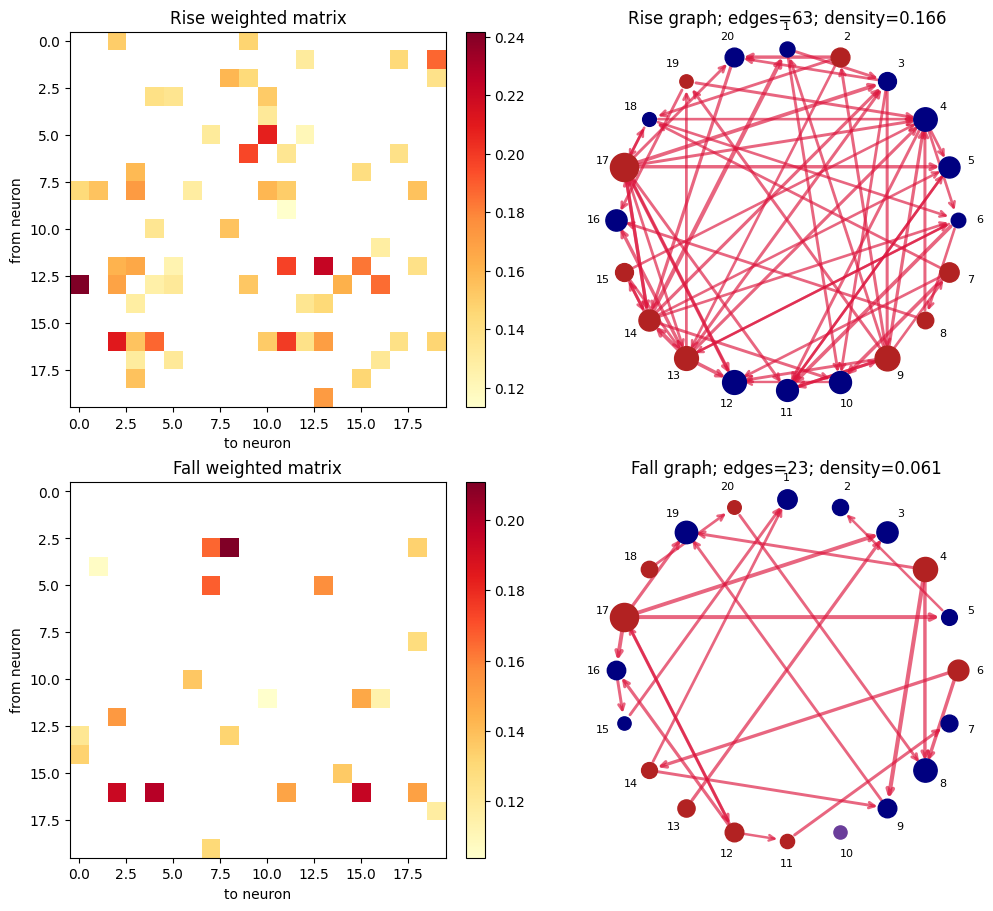

In [7]:
def plot_weighted_matrix(matrix, ax=None):
    axis = plt.gca() if ax is None else ax
    displayed = np.asarray(matrix, dtype=float).copy()
    displayed[displayed == 0.0] = np.nan
    image = axis.imshow(displayed, cmap="YlOrRd")
    axis.set_xlabel("to neuron")
    axis.set_ylabel("from neuron")
    axis.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    return axis


def plot_circular_graph(matrix, ax=None, show_labels=True):
    values = np.asarray(matrix, dtype=float).copy()
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(values, 0.0)
    axis = plt.gca() if ax is None else ax
    n_nodes = values.shape[0]
    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n_nodes, endpoint=False)
    coords = np.column_stack((np.cos(angles), np.sin(angles)))
    drive = values.sum(axis=1) - values.sum(axis=0)
    max_drive = float(np.max(np.abs(drive))) if drive.size else 0.0
    scaled = drive if max_drive == 0.0 else drive / max_drive
    colors = np.where(scaled > 0, "firebrick", np.where(scaled < 0, "navy", "#6a3d9a"))

    for node, center in enumerate(coords):
        axis.scatter(*center, s=90 + 320 * abs(scaled[node]), c=colors[node], zorder=3)
        if show_labels and n_nodes <= 35:
            axis.text(center[0] * 1.13, center[1] * 1.13, str(node + 1), ha="center", va="center", fontsize=8)

    positive = values[values > 0.0]
    scale = float(positive.max()) if positive.size else 1.0
    for source, target in zip(*np.nonzero(values > 0.0)):
        if source == target:
            continue
        axis.annotate(
            "",
            xy=coords[target],
            xytext=coords[source],
            arrowprops={
                "arrowstyle": "->",
                "color": "crimson",
                "lw": 0.6 + 2.4 * values[source, target] / scale,
                "alpha": 0.65,
                "shrinkA": 7,
                "shrinkB": 7,
            },
            zorder=2,
        )
    axis.set_aspect("equal")
    axis.axis("off")
    return axis


def plot_phase(cache, phase, axes):
    payload = cache["record"]["graphs"][phase]
    matrix = np.asarray(payload["weighted_adjacency"], dtype=float)
    summary = payload.get("summary")
    if summary is None:
        off_diag = ~np.eye(matrix.shape[0], dtype=bool)
        retained_edges = int(np.count_nonzero(matrix[off_diag] > 0.0))
        opportunities = int(np.count_nonzero(off_diag))
        summary = {
            "retained_edges": retained_edges,
            "edge_density": retained_edges / opportunities if opportunities else 0.0,
        }
    plot_weighted_matrix(matrix, ax=axes[0])
    axes[0].set_title(f"{phase.title()} weighted matrix")

    if PLOT_MODE == "topographic":
        centers = record.get("cell_centers")
        background = record.get("background")
        if centers is None or background is None:
            raise ValueError("Topographic plot requires cell centers and background.")
        plot_topographic_graph(matrix, centers, background, ax=axes[1], show_labels=True)
    else:
        plot_circular_graph(matrix, ax=axes[1])
    axes[1].set_title(
        f"{phase.title()} graph; edges={summary['retained_edges']}; density={summary['edge_density']:.3f}"
    )


cache = adjacency_cache if "adjacency_cache" in globals() else load_adjacency_cache()
fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
plot_phase(cache, "rise", axes[0])
plot_phase(cache, "fall", axes[1])
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_OUTPUT_FILE, dpi=300, bbox_inches="tight")
print(f"Saved figure to {FIGURE_OUTPUT_FILE}")
plt.show()
